# Lecture 6b — Forecasting and Nowcasting ESG Series

**AI-integrated Sustainable Finance (25881) · Spring 2026**

Notebook 6a established what the series *is*. This one asks what can be done
with it, in the order a careful analyst would work:

1. **Benchmarks first.** Three forecasts that cost nothing. If you cannot beat
   them, you have no result.
2. **Reduce forecasting to regression.** Lag features, calendar features and the
   Fourier terms 6a selected — then any scikit-learn model.
3. **Break a gradient booster**, understand why, and fix it in one line.
4. **Score everything on a rolling-origin backtest**, because a single split
   measures one lucky draw.
5. **Earn your intervals** from backtest residuals rather than assuming them.
6. **Nowcast**, and discover why the proxy that looks brilliant is useless.

Only `scikit-learn` and `statsforecast` are used. No deep learning: on a series
this size it would lose, and you would not be able to see why.

<details>
<summary><b>Show the maths: why we forecast CO₂ rather than an ESG score</b></summary>

We need a target where the honest answer is not "this is unforecastable", or the
whole methodological apparatus becomes theatre. From the lecture's forecastability
table, atmospheric CO₂ is the one series where a well-specified model should
comfortably beat a naive benchmark: slow trend, rigid seasonality, small noise.

The cost is that every result here is optimistic relative to what you will get on
disclosed corporate emissions. Section 7 restores the balance by showing a proxy
relationship collapsing under exactly the transformation that should preserve it.

</details>

---
## 0. Setup

Same helper module as 6a. If you ran that notebook, the data is already cached.

In [1]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

import esgts6 as E

E.use_house_theme()
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

SEASON = 12
LAGS = (1, 2, 3, 12)
K_FOURIER = 2                 # chosen in notebook 6a by the periodogram, not by search
H = 12                        # forecast horizon, in months

co2 = E.load_mauna_loa()
y = co2["co2"].loc["1980":].dropna()
print(f"{len(y)} monthly observations, {y.index.min():%Y-%m} to {y.index.max():%Y-%m}")

559 monthly observations, 1980-01 to 2026-07


---
## 1. Benchmarks first

Four forecasts, none of which involves fitting anything. Note the fourth: plain
seasonal naive ignores the trend entirely, which makes it too easy a target on a
series that is rising. **Seasonal naive plus drift** is the benchmark that
deserves respect.

In [2]:
train, test = y.loc[:"2024-12-01"], y.loc["2025-01-01":"2025-12-01"]

benchmarks = {
    "Naive":            E.naive(train, H),
    "Drift":            E.drift(train, H),
    "SeasonalNaive":    E.seasonal_naive(train, H, SEASON),
    "SeasNaive+drift":  E.seasonal_naive_drift(train, H, SEASON),
}

for name, pred in benchmarks.items():
    print(f"{name:<18} MAE {E.mae(test, pred):6.3f} ppm    "
          f"MASE {E.mase(test, pred, train.values, SEASON):6.3f}")

Naive              MAE  2.209 ppm    MASE  1.132
Drift              MAE  1.992 ppm    MASE  1.021
SeasonalNaive      MAE  2.745 ppm    MASE  1.407
SeasNaive+drift    MAE  0.815 ppm    MASE  0.418


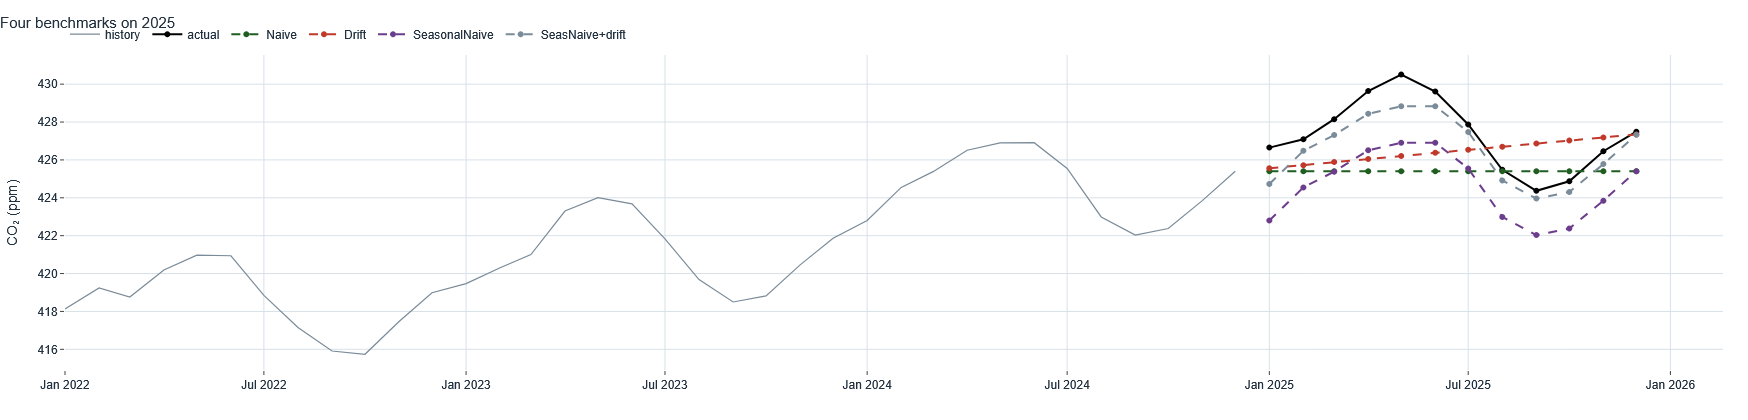

In [3]:
E.plot_forecast(train, actual=test, forecasts=benchmarks,
                title="Four benchmarks on 2025", ylab="CO₂ (ppm)", n_history=36).show()

### Reading MASE correctly

Notice that `SeasonalNaive` scores **above 1**. That is not a bug, and it is worth
understanding before you interpret any table in this notebook.

<details>
<summary><b>Show the maths: what the MASE denominator actually is</b></summary>

$$
\text{MASE} = \frac{\frac{1}{h}\sum_{j=1}^{h}\left|y_{T+j}-\hat{y}_{T+j}\right|}
{\frac{1}{n-m}\sum_{t=m+1}^{n}\left|y_t-y_{t-m}\right|}
$$

The numerator is the out-of-sample error of an $h$-step forecast. The denominator
is the **in-sample, one-step** seasonal naive error, computed from the training
data alone.

Those are not the same task. Forecasting twelve months ahead is harder than
forecasting one month ahead, so a 12-step seasonal naive forecast will score
above 1 on a trending series almost by construction. MASE $= 1$ therefore means
"as accurate as a one-step seasonal naive forecast", which is a demanding bar,
not a trivial one.

Two properties make it worth the confusion: it is scale-free, so ppm, tonnes and
dollars are comparable; and unlike MAPE it does not explode when the series
passes through zero — which matters constantly, because ESG targets are usually
emissions *changes*.

</details>

> **Exercise 1 (Core).** Compute MASE for the same four benchmarks at $h = 1$
> instead of 12. Does `SeasonalNaive` drop below 1? Explain the result in terms
> of the denominator above.

---
## 2. Forecasting as supervised learning

There is no special "ML forecasting" library needed. Reduce the series to a
feature matrix where each row uses only the past, and any regressor will do.

Three feature families:

- **lags** — `lag_1, lag_2, lag_3, lag_12`: short memory plus last year.
- **calendar** — `sin_1, cos_1, sin_2, cos_2`: the $K=2$ harmonics at period 12
  that the periodogram selected in 6a.
- **trend** — `t`: a linear time index. Read Section 4 before you trust it.

In [4]:
X, target = E.build_training(train.values, t0=0, lags=LAGS, K=K_FOURIER, season=SEASON)
print(f"design matrix: {X.shape[0]} rows x {X.shape[1]} features")
print(X.columns.tolist())
X.head()

design matrix: 528 rows x 9 features
['lag_1', 'lag_2', 'lag_3', 'lag_12', 'sin_1', 'cos_1', 'sin_2', 'cos_2', 't']


,lag_1,lag_2,lag_3,lag_12,sin_1,cos_1,sin_2,cos_2,t
0,338.290,337.300,336.140,337.900,-0.000,1.000,-0.000,1.000,12.000
1,339.290,338.290,337.300,338.340,0.500,0.866,0.866,0.500,13.000
2,340.550,339.290,338.290,340.070,0.866,0.500,0.866,-0.500,14.000
3,341.630,340.550,339.290,340.930,1.000,0.000,0.000,-1.000,15.000
4,342.600,341.630,340.550,341.450,0.866,-0.500,-0.866,-0.500,16.000


The construction is deliberately explicit. Row $i$ is built from `values[:i]`, so
**no row can see its own target**. That single line is the whole of the
look-ahead defence at this stage — read `E.build_training` if you want to check.

In [5]:
model = make_pipeline(StandardScaler(), Ridge(alpha=1.0))
model.fit(X, target)

pred = E.recursive_forecast(model, train.values, t_start=len(train), h=H,
                            lags=LAGS, K=K_FOURIER, season=SEASON)

print(f"Ridge on levels   MAE {E.mae(test, pred):.3f} ppm    "
      f"MASE {E.mase(test, pred, train.values, SEASON):.3f}")
print(f"best benchmark    MASE {E.mase(test, benchmarks['SeasNaive+drift'], train.values, SEASON):.3f}")

Ridge on levels   MAE 0.413 ppm    MASE 0.212
best benchmark    MASE 0.418


<details>
<summary><b>Show the maths: recursive versus direct multi-step forecasting</b></summary>

**Recursive.** Fit one model $f$ for the one-step problem, then iterate:
$\hat{y}_{T+1}=f(y_T,\dots)$, $\hat{y}_{T+2}=f(\hat{y}_{T+1},y_T,\dots)$, and so
on. Predictions become inputs. Coherent across horizons and cheap, but errors
compound: a poor step-one forecast contaminates every step after it.

**Direct.** Fit a separate model $f_j$ for each horizon $j$, each mapping the
information available at $T$ straight to $y_{T+j}$. No compounding, but $h$ times
the fitting work, and nothing forces the resulting path to be coherent — the
$h=3$ forecast need not sit sensibly between $h=2$ and $h=4$.

Neither dominates in general. `E.recursive_forecast` implements the first; the
second is Exercise 3.

</details>

> **Exercise 2 (Core).** Drop the Fourier terms (`K=0`) and refit. How much
> accuracy came from the four calendar features that 6a selected?
>
> **Exercise 3 (Stretch).** Implement the direct strategy: fit twelve separate
> Ridge models, one per horizon. Does it beat the recursive version here? On what
> kind of series would you expect the ranking to flip?

---
## 3. Break a gradient booster

Same features, same data, same recursive loop. Swap the model and watch what
happens over a long horizon.

In [6]:
CUT = "2015-12-01"
tr, te = y.loc[:CUT], y.loc["2016-01-01":]
H_LONG = len(te)

def make_models():
    return {
        "Ridge": make_pipeline(StandardScaler(), Ridge(alpha=1.0)),
        "RandomForest": RandomForestRegressor(n_estimators=300, min_samples_leaf=2,
                                              random_state=0, n_jobs=-1),
        "HistGB": HistGradientBoostingRegressor(max_iter=300, learning_rate=0.06,
                                                random_state=0),
    }

Xtr, ytr = E.build_training(tr.values, t0=0, lags=LAGS, K=K_FOURIER, season=SEASON)

preds_level = {}
for name, m in make_models().items():
    m.fit(Xtr, ytr)
    preds_level[name] = E.recursive_forecast(m, tr.values, len(tr), H_LONG,
                                             lags=LAGS, K=K_FOURIER, season=SEASON)
    print(f"{name:<14} MAE over {H_LONG} months: {E.mae(te, preds_level[name]):6.2f} ppm")

Ridge          MAE over 127 months:   4.43 ppm
RandomForest   MAE over 127 months:  13.18 ppm
HistGB         MAE over 127 months:  15.38 ppm


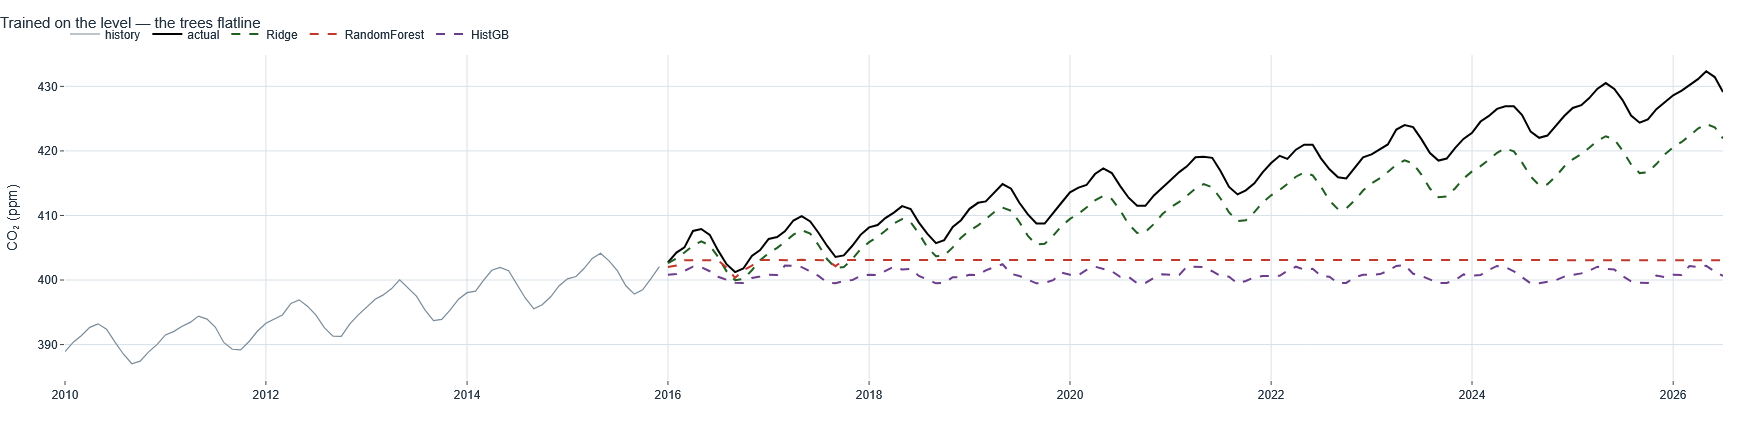

In [7]:
E.plot_forecast(tr, actual=te, forecasts=preds_level,
                title="Trained on the level — the trees flatline",
                ylab="CO₂ (ppm)", n_history=72, height=430).show()

*Your MAE values will sit a little away from the lecture slides -- around 4.4,
13.2 and 15.1 rather than 4.4, 13.1 and 15.0. The slides were built when the
series ended one month earlier, so the horizon here is one month longer. Same
conclusion, slightly different arithmetic; the rolling-origin table in Section 4
is unaffected because the extra month does not add an origin.*

The trees do not merely forecast badly. They stop moving.

A tree predicts by averaging the training observations that fall in a leaf, so
**its output can never leave the range of targets it was trained on**. No split
on `t` can reach a date it has never seen. The linear model extrapolates because
that is what a linear function does; the trees cannot, in principle.

The fix is not a better tree. It is to change what you ask the model to predict.

In [8]:
# Predict the CHANGE, then cumulate back to the level.
d_tr = tr.diff().dropna()
Xd, yd = E.build_training(d_tr.values, t0=max(LAGS), lags=LAGS, K=K_FOURIER,
                          season=SEASON, with_trend=False)

preds_diff = {}
for name, m in make_models().items():
    m.fit(Xd, yd)
    d_hat = E.recursive_forecast(m, d_tr.values, len(d_tr) + max(LAGS), H_LONG,
                                 lags=LAGS, K=K_FOURIER, season=SEASON, with_trend=False)
    preds_diff[name] = tr.values[-1] + np.cumsum(d_hat)

comparison = pd.DataFrame({
    "MAE on the level": {k: E.mae(te, v) for k, v in preds_level.items()},
    "MAE on the difference": {k: E.mae(te, v) for k, v in preds_diff.items()},
})
comparison["improvement"] = comparison.iloc[:, 0] / comparison.iloc[:, 1]
print(comparison.round(2).to_string())

              MAE on the level  MAE on the difference  improvement
Ridge                    4.430                  3.610        1.230
RandomForest            13.180                  2.520        5.220
HistGB                  15.380                  1.850        8.290


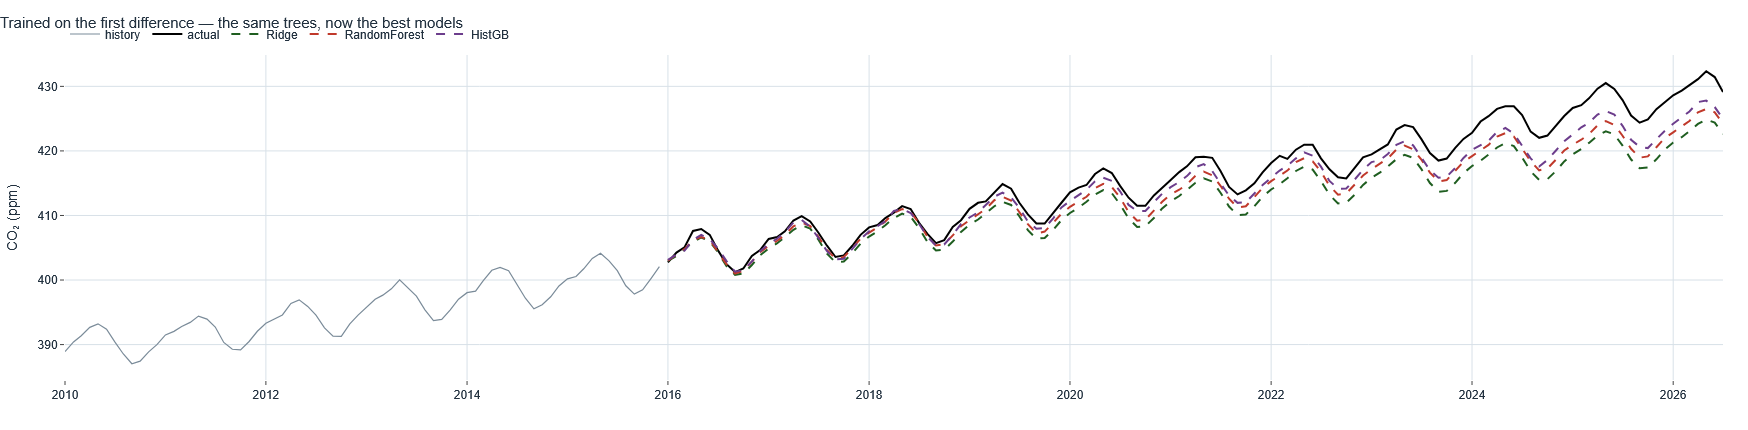

In [9]:
E.plot_forecast(tr, actual=te, forecasts=preds_diff,
                title="Trained on the first difference — the same trees, now the best models",
                ylab="CO₂ (ppm)", n_history=72, height=430).show()

Differencing moves the target back inside the range the model saw in training.
Nothing about the algorithms changed; the representation did.

> **Exercise 4 (Core).** Try a *seasonal* difference ($y_t - y_{t-12}$) instead of
> a first difference. Does it help more or less? Why might it be the more natural
> choice here, given what 6a found?
>
> **Exercise 5 (Stretch).** Remove the `t` feature entirely from the level-trained
> models (`with_trend=False`) and refit. Does the tree improve, stay the same, or
> get worse? Use the answer to state precisely what `t` was contributing.

---
## 4. The bake-off

One train/test split measures one lucky draw. Refit at a sequence of expanding
origins and score every model on all of them.

`E.rolling_origin` hands each forecaster a `history` Series that ends **strictly
before** its origin, so a model physically cannot see its own test period. The
MASE denominator is recomputed from each origin's own history — using the full
sample would leak the test period into the scale.

In [10]:
def sk_forecaster(name, differenced):
    "Wrap a scikit-learn model as a history -> forecast function."
    def f(hist, h):
        m = make_models()[name]
        if differenced:
            d = hist.diff().dropna()
            Xd_, yd_ = E.build_training(d.values, t0=max(LAGS), lags=LAGS,
                                        K=K_FOURIER, season=SEASON, with_trend=False)
            m.fit(Xd_, yd_)
            dh = E.recursive_forecast(m, d.values, len(d) + max(LAGS), h,
                                      lags=LAGS, K=K_FOURIER, season=SEASON,
                                      with_trend=False)
            return hist.values[-1] + np.cumsum(dh)
        Xh_, yh_ = E.build_training(hist.values, t0=0, lags=LAGS,
                                    K=K_FOURIER, season=SEASON)
        m.fit(Xh_, yh_)
        return E.recursive_forecast(m, hist.values, len(hist), h,
                                    lags=LAGS, K=K_FOURIER, season=SEASON)
    return f

forecasters = {
    "SeasonalNaive":   lambda hist, h: E.seasonal_naive(hist, h, SEASON),
    "Drift":           lambda hist, h: E.drift(hist, h),
    "SeasNaive+drift": lambda hist, h: E.seasonal_naive_drift(hist, h, SEASON),
}
for nm in ["Ridge", "RandomForest", "HistGB"]:
    forecasters[nm] = sk_forecaster(nm, differenced=False)
    forecasters[f"{nm} (diff)"] = sk_forecaster(nm, differenced=True)

bt = E.rolling_origin(y, forecasters, h=H, season=SEASON,
                      first_origin="2011-01-01", step=12, min_train=120)
print(f"{bt.origin.nunique()} origins x {bt.model.nunique()} models")

15 origins x 9 models


In [11]:
summary = (bt.groupby("model")
             .agg(MASE=("MASE", "mean"), worst=("MASE", "max"), MAE=("MAE", "mean"))
             .sort_values("MASE"))
wins = bt.pivot(index="origin", columns="model", values="MASE").idxmin(axis=1).value_counts()
summary["wins"] = wins.reindex(summary.index).fillna(0).astype(int)
summary.round(3)

,MASE,worst,MAE,wins
model,,,,
Ridge (diff),0.228,0.466,0.417,5
RandomForest (diff),0.240,0.895,0.444,5
HistGB (diff),0.257,0.689,0.472,4
Ridge,0.333,0.769,0.607,1
SeasNaive+drift,0.407,0.911,0.746,0
RandomForest,0.727,1.132,1.328,0
Drift,1.118,1.232,2.037,0
SeasonalNaive,1.359,1.912,2.483,0
HistGB,1.526,2.053,2.789,0


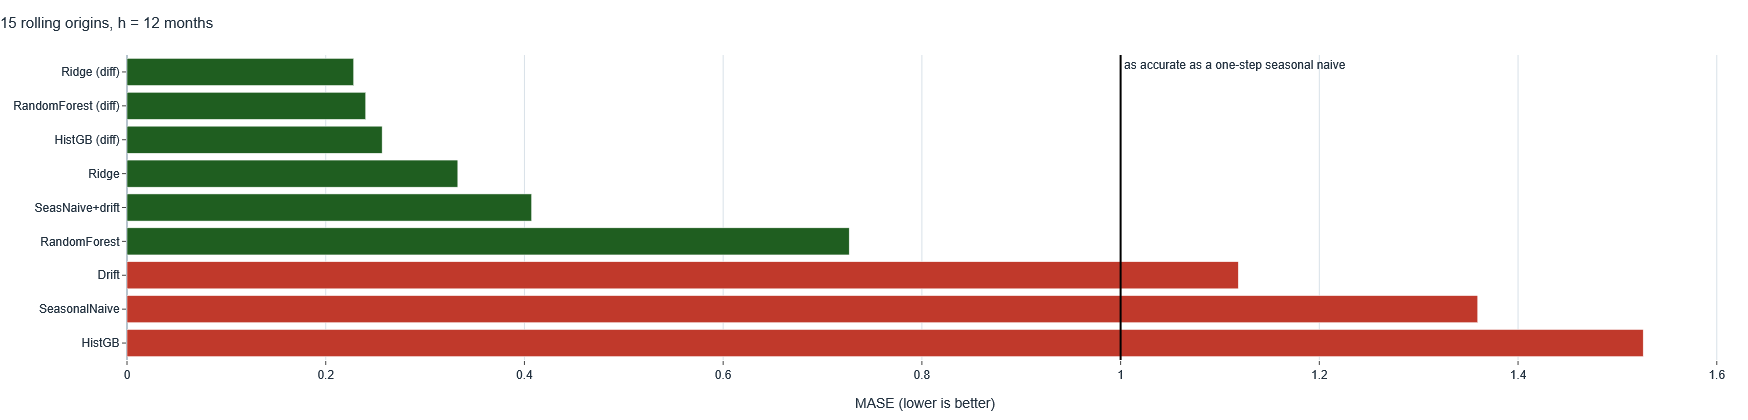

In [12]:
sm = summary.sort_values("MASE", ascending=False)
fig = go.Figure(go.Bar(
    x=sm.MASE, y=sm.index, orientation="h",
    marker_color=[E.COLOURS["dark_green"] if v < 1 else E.COLOURS["red"] for v in sm.MASE]))
fig.add_vline(x=1.0, line_color="black", line_width=2,
              annotation_text="as accurate as a one-step seasonal naive")
fig.update_layout(title=f"{bt.origin.nunique()} rolling origins, h = {H} months",
                  xaxis_title="MASE (lower is better)", height=420)
fig.show()

Three things fall out of that table, and only one of them is about models.

**Preprocessing beat model choice, and it was not close.** Every model improves
enormously when the target is differenced. The gap between a model's level and
differenced versions dwarfs the gap between any two models.

**Once the representation is right, the algorithm barely matters.** The three
differenced models finish within a few percent of each other. If you had spent
the afternoon tuning hyperparameters instead of thinking about the target, you
would have bought almost nothing.

**A flexible model on the wrong target is worse than doing nothing.** Check where
`HistGB` on levels lands relative to the benchmarks.

Also worth noting: the model with the best *mean* MASE is not necessarily the one
that wins the most *origins*. Decide your ranking rule before you look at the
table, not after.

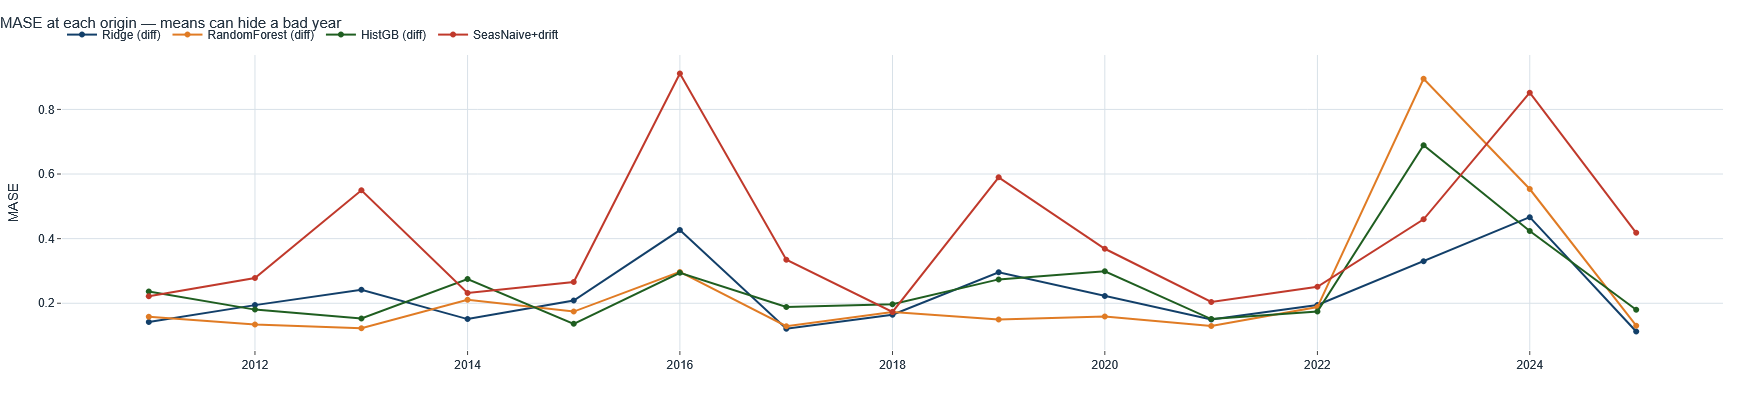

In [13]:
# Per-origin detail: is the winner consistent, or is the mean hiding volatility?
pivot = bt.pivot(index="origin", columns="model", values="MASE")
best = summary.index[:3].tolist() + ["SeasNaive+drift"]
fig = go.Figure()
for m in best:
    fig.add_trace(go.Scatter(x=pivot.index, y=pivot[m], mode="lines+markers", name=m))
fig.update_layout(title="MASE at each origin — means can hide a bad year",
                  yaxis_title="MASE", height=400)
fig.show()

> **Exercise 6 (Core).** Change `step` to 6 so you get roughly twice as many
> origins. Does the ranking survive? If it does not, what does that tell you about
> how much confidence the original table deserved?
>
> **Exercise 7 (Core).** Add `AutoETS` and `AutoARIMA` from `statsforecast` as two
> more forecasters and rerun. They are univariate and classical; do they beat the
> ML recipe here?

In [14]:
# Scaffold for Exercise 7. statsforecast's first import compiles numba kernels,
# so expect this cell to be slow the first time and fast afterwards.
import warnings
warnings.filterwarnings("ignore", message=".*IProgress.*")

try:
    from statsforecast.models import AutoETS

    def ets_forecaster(hist, h):
        m = AutoETS(season_length=SEASON)
        m.fit(hist.values.astype(np.float64))
        return m.predict(h)["mean"]

    # Score it on the SAME single split as Sections 1-2, so the comparison is
    # like for like.
    hist_2024 = y.loc[:"2024-12-01"]
    for label, pred in [
        ("AutoETS",         ets_forecaster(hist_2024, H)),
        ("Ridge (diff)",    forecasters["Ridge (diff)"](hist_2024, H)),
        ("SeasNaive+drift", E.seasonal_naive_drift(hist_2024, H, SEASON)),
    ]:
        print(f"{label:<18} MASE on 2025 only: {E.mase(test, pred, hist_2024.values, SEASON):.3f}")
except ImportError:
    print("statsforecast not installed - run: pip install statsforecast")
except Exception as exc:
    print(f"statsforecast present but the call failed ({exc}).")
    print("Check the API for your version; older releases return a bare array.")

statsforecast not installed - run: pip install statsforecast


**Do not compare those numbers to the bake-off table.** They are single-origin
scores on one twelve-month window; the table averages fifteen. A model can look
excellent on 2025 and mediocre across the full set of origins, which is the
entire reason we built the rolling backtest.

That is what Exercise 7 is really asking: put the classical models through
`E.rolling_origin` alongside everything else, and see whether the single-split
impression survives.

---
## 5. Intervals you earned

A point forecast of an ESG metric is an assertion. An interval is a claim you can
be held to.

You already ran the backtest. Keep the residuals, bucket them **by horizon**, and
read the quantiles straight off. No distributional assumption, no
$\sigma\sqrt{h}$ formula that assumes away the seasonality.

In [15]:
BEST = summary.index[0]
print(f"building intervals for: {BEST}")

resid_by_h = {j: [] for j in range(H)}
origins = pd.date_range("2011-01-01", y.index[-1], freq="12MS")
for origin in origins:
    hist = y.loc[:origin - pd.offsets.MonthBegin(1)]
    fut = y.loc[origin:origin + pd.offsets.MonthBegin(H - 1)]
    if len(fut) < H or len(hist) < 120:
        continue
    p = np.asarray(forecasters[BEST](hist, H), float)
    for j in range(H):
        resid_by_h[j].append(fut.values[j] - p[j])

lo = np.array([np.quantile(resid_by_h[j], 0.10) for j in range(H)])
hi = np.array([np.quantile(resid_by_h[j], 0.90) for j in range(H)])

print(f"residual samples per horizon: {len(resid_by_h[0])}")
print(f"80% interval width at h=1 : {hi[0] - lo[0]:.2f} ppm")
print(f"80% interval width at h={H}: {hi[-1] - lo[-1]:.2f} ppm")

building intervals for: Ridge (diff)
residual samples per horizon: 15
80% interval width at h=1 : 0.74 ppm
80% interval width at h=12: 0.89 ppm


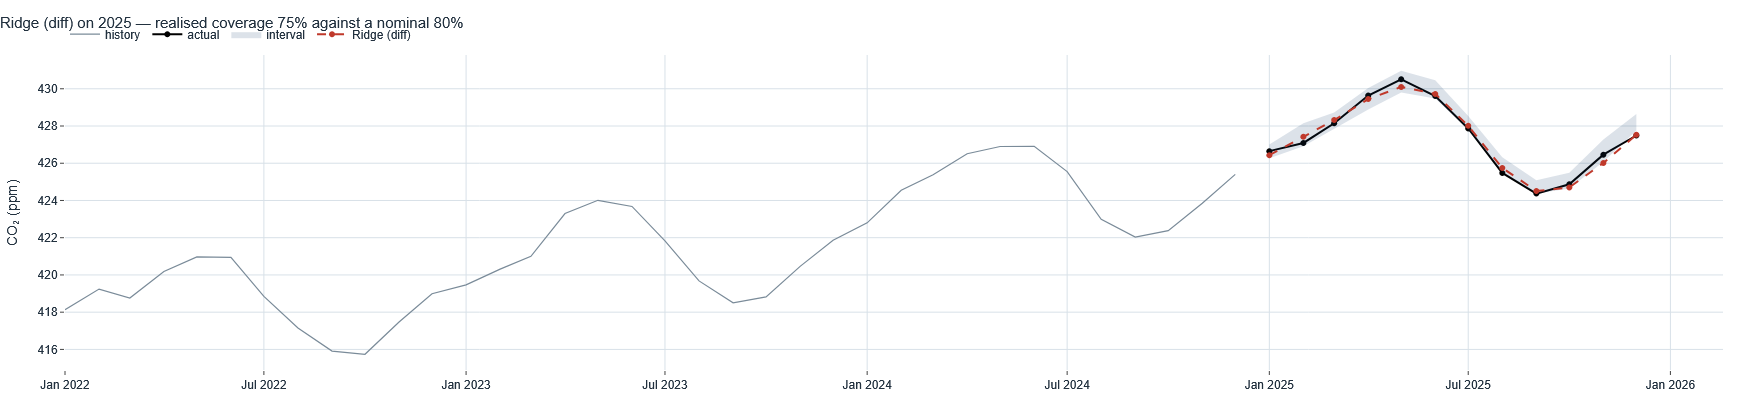

In [16]:
hist = y.loc[:"2024-12-01"]
point = np.asarray(forecasters[BEST](hist, H), float)
coverage = np.mean((test.values >= point + lo) & (test.values <= point + hi))

E.plot_forecast(hist, actual=test, forecasts={BEST: point},
                interval=(point + lo, point + hi),
                title=f"{BEST} on 2025 — realised coverage {coverage:.0%} against a nominal 80%",
                ylab="CO₂ (ppm)", n_history=36).show()

Two cautions before you reuse this anywhere.

**The interval barely widens with horizon here.** That is a property of this
series, not of the method: the seasonal component is nearly deterministic, so
$h=12$ is not much harder than $h=1$. On a series with a stochastic trend the
band will fan out roughly as $\sqrt{h}$. Do not carry the shape across.

**Count your residuals.** Each quantile is estimated from a handful of numbers —
print `len(resid_by_h[0])` and look at it. Report that count next to any coverage
figure, because a 10th percentile estimated from fifteen observations is not a
precise object.

> **Exercise 8 (Core).** Compute realised coverage across *all* backtest origins
> rather than just 2025, using leave-one-origin-out so the interval is never
> built from the year it is scored on. Is the nominal 80% honest?
>
> **Exercise 9 (Stretch).** Residual quantiles assume the future resembles the
> backtest window. Construct the case where that fails: pick a break point, build
> intervals from data before it only, and measure coverage after it.

---
## 6. Nowcasting — and the trap

Reported emissions run about two years behind. So the operational question is
rarely "what will 2028 look like". It is **"what is happening now?"** — inferring
an unpublished value from a proxy that arrives fast.

Atmospheric CO₂ growth is available within weeks. National emissions are not.
Does the fast series tell us about the slow one?

In [17]:
owid = E.load_owid(columns=["country", "year", "co2"])
world = owid.query("country == 'World'").set_index("year")["co2"].dropna()

annual_mean = co2["co2"].resample("YE").mean()
annual_mean.index = annual_mean.index.year
growth = annual_mean.diff().dropna()

df = pd.concat([world.rename("emissions"), growth.rename("ppm_growth")], axis=1).dropna().loc[1960:]

def ols_r2(x, yv):
    X_ = np.column_stack([np.ones(len(x)), x])
    b = np.linalg.lstsq(X_, yv, rcond=None)[0]
    return 1 - np.var(yv - X_ @ b) / np.var(yv)

print(f"n = {len(df)} years, {df.index.min()}–{df.index.max()}")
print(f"levels   corr {df.emissions.corr(df.ppm_growth):.3f}   R² {ols_r2(df.ppm_growth, df.emissions):.3f}")

n = 65 years, 1960–2024
levels   corr 0.777   R² 0.604


An $R^2$ of about 0.6 from a proxy available in near real time. That looks like a
usable nowcast.

Now ask the only question a decision-maker actually cares about: **did emissions
rise or fall this year?** That is a question about changes, not levels.

changes  corr 0.054   R² 0.0029


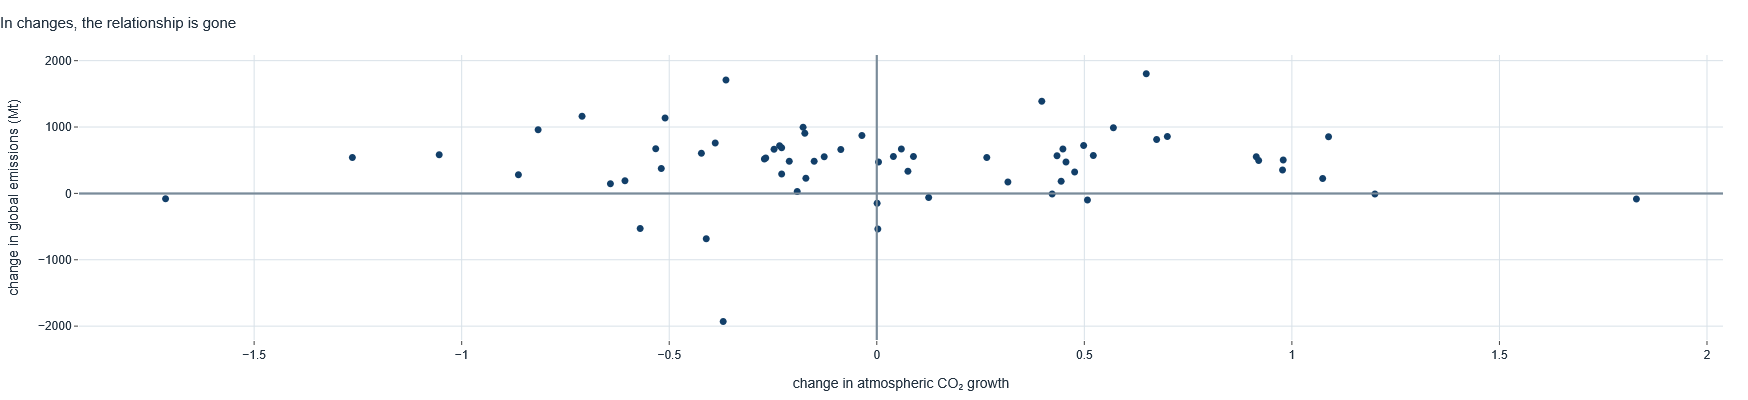

In [18]:
d = df.diff().dropna()
print(f"changes  corr {d.emissions.corr(d.ppm_growth):.3f}   R² {ols_r2(d.ppm_growth, d.emissions):.4f}")

fig = go.Figure(go.Scatter(x=d.ppm_growth, y=d.emissions, mode="markers",
                           marker=dict(size=7, color=E.COLOURS["blue"])))
fig.add_hline(y=0, line_color=E.COLOURS["grey"]); fig.add_vline(x=0, line_color=E.COLOURS["grey"])
fig.update_layout(title="In changes, the relationship is gone",
                  xaxis_title="change in atmospheric CO₂ growth",
                  yaxis_title="change in global emissions (Mt)", height=400)
fig.show()

The level fit was two trends passing in the night. Both series rise over the
sample; regressing one on the other measures that shared trend and essentially
nothing else. Difference them and the apparent relationship evaporates.

**Always difference before you believe a proxy.** A nowcast that cannot call the
sign of the change is not a nowcast, whatever its $R^2$.

This is a negative result and it is presented as one. It does not mean nowcasting
is impossible — it means *this* proxy fails, for a reason you can now diagnose in
one line. Higher-frequency physical proxies (grid generation, satellite column
measurements, shipping activity) are where the working versions come from.

> **Exercise 10 (Core).** Repeat the levels-versus-changes comparison for a single
> large emitter rather than the world total. Does any country's emissions change
> track the atmospheric signal? Should you expect one to?
>
> **Exercise 11 (Stretch).** Build an honest nowcast of the *unpublished* year.
> Train on data through year $Y-1$, predict $Y$, and evaluate only against
> vintages that were published later. Use `E.load_owid_vintage` to get the
> published-at-the-time values. Report the sign accuracy, not just the MAE.

---
## What to carry forward

1. **Benchmarks are not a formality.** Report the benchmark's score in every
   table you produce. A result without one is not a result.
2. **The target representation matters more than the model.** Differencing moved
   the trees from worst to best. No hyperparameter search would have found that.
3. **Refit at every origin.** A single split measures one draw, and the spread
   across origins is usually larger than the spread across models.
4. **Intervals should be earned from backtest residuals**, and reported alongside
   the number of residuals they were estimated from.
5. **Difference before you believe a proxy.** $R^2 = 0.60$ in levels became
   $0.003$ in changes, and the second number is the honest one.

For the group assignment: run your chosen series through the 6a checklist
*before* you fit anything here. If it fails — if `flat_share` is high, or the
periodogram finds nothing you can name a mechanism for — that finding is itself a
legitimate result, and a better one than a forecast you cannot defend.